# 01 - hex_proximity_plot()

This notebook __creates function hex_proximity_plot()__ based on existing hex_plot() function.

## __Import libraries__

In [1]:
from pathlib import Path

current_path = Path().resolve()

for parent in current_path.parents:
    if parent.name == "odc":
        project_root = parent
        break

print(project_root)

/home/jovyan/odc


In [2]:
import os
import sys

import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

module_path = os.path.abspath(os.path.join(project_root))
if module_path not in sys.path:
    sys.path.append(module_path)
    print("Path found")
    import odc

Path found


## __Config notebook__

In [3]:
res = 8
city = 'Aguascalientes'

## __Load data__

In [4]:
# Load data test
data_schema = 'prox_analysis'
data_table = f'proximityanalysis_v2_23_mzaageb_hex'
# Load city's hexs filtering for urban areas if required
query = f"SELECT * FROM {data_schema}.{data_table} WHERE \"city\" = '{city}\' AND \"res\" = '{res}\'"
data_gdf = odc.gdf_from_query(query, geometry_col='geometry')

# Show
print(data_gdf.crs)
print(data_gdf.shape)
data_gdf.head(2)

epsg:4326
(326, 69)


,hex_id,res,geometry,max_escuelas,max_preescolar,max_primaria,max_secundaria,max_servicios comunitarios,max_salud,max_guarderías,...,pobmas,p_0a5,p_6a11,p_12a17,p_18a24,p_25a59,p_60ymas,pcon_disc,dens_pob_ha,city
0,88498e36e9fffff,8,"POLYGON ((-102.29272 21.90980, -102.28813 21.9...",27.992034,16.074035,19.779315,27.992034,32.490184,19.020417,19.214431,...,78.561676,7.266604,11.098653,11.460846,18.28267,68.929773,42.874687,6.268474,1.856889,Aguascalientes
1,884988d947fffff,8,"POLYGON ((-102.33664 21.85872, -102.33205 21.8...",36.404626,16.123503,23.844778,36.404626,50.537748,50.537748,25.462228,...,621.509460,63.252146,81.498460,148.321590,155.81941,606.319750,175.803940,40.546770,14.270372,Aguascalientes


In [5]:
# Download area of interest (aoi)
print('--- Downloading area of interest.')
metro_schema = 'metropolis'
metro_table = 'metro_gdf_2020'
query = f"SELECT * FROM {metro_schema}.{metro_table} WHERE \"city\" LIKE \'{city}\'"
mun_gdf = odc.gdf_from_query(query, geometry_col='geometry')
mun_gdf = mun_gdf.set_crs("EPSG:4326")
aoi = mun_gdf.dissolve()

# Download Network (G, nodes, edges)
print('--- Downloading network.')
network_schema = 'osmnx'
nodes_table = 'nodes_osmnx_23_point'
edges_table = 'edges_speed_23_line'
G, nodes_gdf, edges_gdf = odc.graph_from_hippo(aoi, schema=network_schema, edges_folder=edges_table, nodes_folder=nodes_table)

# Show
print(edges_gdf.crs)
print(edges_gdf.shape)
edges_gdf.head(2)

--- Downloading area of interest.
--- Downloading network.
EPSG:4326
(128150, 19)


osmid  oneway                   name  \
u          v          key                                             
8414611560 1729024510 0    906116849   False  Boulevard Guadalupano   
           2304455693 0    906116850    True  Boulevard Guadalupano   

                             highway  length  \
u          v          key                      
8414611560 1729024510 0    secondary  53.013   
           2304455693 0    secondary  11.792   

                                                                    geometry  \
u          v          key                                                      
8414611560 1729024510 0    LINESTRING (-102.25354 21.91028, -102.25343 21...   
           2304455693 0    LINESTRING (-102.25354 21.91028, -102.25353 21...   

                           grade  grade_abs lanes bridge maxspeed     ref  \
u          v          key                                                   
8414611560 1729024510 0   -0.038      0.038     3   None     None  AGS 60   
           2304455693 0    0.000      0.000     3   None       40  AGS 60   

                          access junction service tunnel width  walkspeed  \
u          v          key                                                   
8414611560 1729024510 0     None     None    None   None  None    3.50186   
           2304455693 0     None     None    None   None  None    4.00000   

                           time_min  
u          v          key            
8414611560 1729024510 0    0.908311  
           2304455693 0    0.176880

## __Function development__

In [17]:
def plot_hex_proximity(gdf_data, column, gdf_edges,
                       ax, plot_title,
                       plot_boundary = (False, gdf_boundary),
                       save_png = (False, '../output/figures/plot.png'),
                       png_transparency = False,
                       png_dpi = False,
                       save_pdf = (False, '../output/figures/plot.pdf'),
                       show_plot = True)
 
	"""
	This function creates a plot designed to show proximity analysis values.

	Arguments:
         gdf_data (geopandas.GeoDataFrame): GeoDataFrame with the data to be plotted.
         column (str): Name of the column to plot from the gdf_data GeoDataFrame.
         gdf_edges (geopandas.GeoDataFrame): GeoDataFrame with the edges (streets) from Open Street Map. 
                                             Must contain the column 'highway', which helps categorize roads by type.
         ax (matplotlib.axes): ax to use in the plot
         plot_title (str): Name of the plot title.

    Keyword Arguments:
         plot_boundary (tuple, optional): Tuple containing boolean on position [0]. 
                                         If true, a gdf can be specified on position [1] and a boundary is ploted.
                                         Defaults to (False, gdf_boundary)
        save_png (tuple, optional): Tupple containing boolean on position [0].
                                    If true, a string can be specified on position [1] indicating the directory and file name where the png is saved.
                                    Defaults to (False, '../output/figures/plot.png')
        png_transparency (bool): Saves the png with transparency or not. Defaults to False.
        png_dpi (int): Sets the resolution to be used to save the png. Defaults to 300.
        save_pdf (tuple, optional): Tupple containing boolean on position [0].
                                    If true, a string can be specified on position [1] indicating the directory and file name where the pdf is saved.
                                    Defaults to (False, '../output/figures/plot.pdf') 
		show_plot (bool): Shows the plot or not. Defaults to True.
		
	"""
    # --------------- DIVIDE THE PLOT
    # Create a divider for the provided ax
	divider = make_axes_locatable(ax)
    # Create an axe for the colorbar (which has cax=cax). 
    # The size will be the "size%" of the main ax, while there's a spacing (pad) between the main ax and the colorbar
	cax = divider.append_axes("bottom", size="5%", pad=0.1)
    
    # --------------- PLOT DATA
	# If available, plot data below 0 color black
	if len(gdf_data[gdf_data[column]<=0]) > 0:
		gdf_data[gdf_data[column]<=0].plot(ax=ax,color='#2b2b2b', alpha=0.95, linewidth=0.1, edgecolor='k', zorder=0)
    # Plot proximity data using the viridis color palette (Commonly used for proximity data)
	gdf_data[gdf_data[column]>0].plot(ax=ax,column=column,cmap='viridis',legend=True,
                                      cax=cax,legend_kwds={'label':column,'orientation': "horizontal"},zorder=1)
    # Plot boundary
    if plot_boundary[0]:
        plot_boundary[1].boundary.plot(ax=ax,color='#2b2b2b',linestyle='--',
                                       linewidth=0.5,zorder=2)
	# Plot edges (Main)
	if len(gdf_edges[(gdf_edges['highway']=='motorway') | (gdf_edges['highway']=='motorway_link')]) > 0:
		gdf_edges[(gdf_edges['highway']=='motorway') | (gdf_edges['highway']=='motorway_link')].plot(ax=ax,
                                                                                                     color='#898989',
                                                                                                     alpha=0.5,
                                                                                                     linewidth=2.5,
                                                                                                     zorder=3
                                                                                                    )
    # Plot edges (Primary and secondary)
    edges_shown = ['primary','primary_link','secondary','secondary_link']
	if len(gdf_edges[(gdf_edges['highway'].isin(edges_shown)]) > 0:
		gdf_edges[(gdf_edges['highway'].isin(edges_shown)].plot(ax=ax,
                                                                color='#898989',
                                                                alpha=0.5,
                                                                linewidth=1.0,
                                                                zorder=3
                                                               )
	# Format plot
	ax.set_title(f'{plot_title}',fontdict={'fontsize':30})
	ax.axis('off')
	# Save or show plot
	if save_png[0]:
		plt.savefig(save_png[1],
                    dpi=png_dpi,
                    transparent=png_transparency
                   )
	if save_pdf[0]:
		plt.savefig(save_pdf[1])
	if show_plot:
		plt.show()

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 51)

## __Visualization__

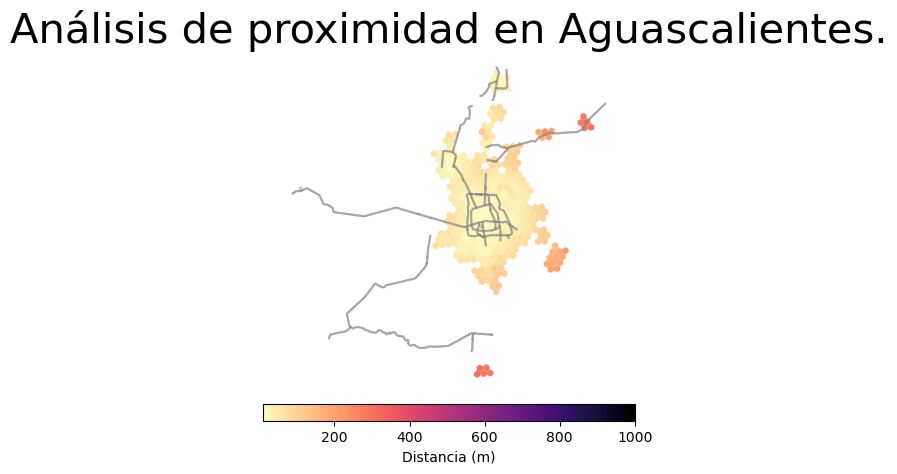

In [8]:
fig,ax = plt.subplots()

odc.hex_plot(ax=ax,
             gdf_data = data_gdf,
             gdf_boundary = data_gdf.dissolve(),
             gdf_edges = edges_gdf,
             column = 'max_time', 
             title = f'Análisis de proximidad en {city}.',
             save_png = False,
save_pdf = False,
show = True,
name = 'plot',
dpi = 300,
transparent = True, 
close_figure = False)